<a href="https://colab.research.google.com/github/edwardsnj/glygen-colab-notebooks/blob/main/variants_original.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#
# Parameters for the figure
#

GLYCOTYPE = "N-linked"
# GLYCOTYPE = "O-linked"

SITETYPE = "experimental"
# SITETYPE = "predicted"


In [2]:
import httpimport, sys, os, os.path

with httpimport.github_repo("edwardsnj", "glygen-colab-notebooks", ref="main"):
  from glygen import GlyGenDownloader
  from variants import extract_datasets, make_plotdata, map_datasets, run_binomial_test

# create directories if necessary
for dirname in ("data","reviewed","plots"):
  if not os.path.exists(dirname):
    os.mkdir(dirname)

human_protein_mutation_files = """
  human_protein_mutation_cancer_all.csv
  human_protein_mutation_germline_all.csv
"""

human_proteoform_glycosylation_site_files = """
  human_proteoform_glycosylation_sites_carbbank.csv
  human_proteoform_glycosylation_sites_c_man.csv
  human_proteoform_glycosylation_sites_diabetes_glycomic.csv
  human_proteoform_glycosylation_sites_embl.csv
  human_proteoform_glycosylation_sites_glycomeatlas.csv
  human_proteoform_glycosylation_sites_glyconnect.csv
  human_proteoform_glycosylation_sites_gptwiki.csv
  human_proteoform_glycosylation_sites_harvard.csv
  human_proteoform_glycosylation_sites_literature.csv
  human_proteoform_glycosylation_sites_literature_mining.csv
  human_proteoform_glycosylation_sites_literature_mining_manually_verified.csv
  human_proteoform_glycosylation_sites_oglcnac_atlas.csv
  human_proteoform_glycosylation_sites_oglcnac_mcw.csv
  human_proteoform_glycosylation_sites_o_gluc.csv
  human_proteoform_glycosylation_sites_o_gluc_predicted.csv
  human_proteoform_glycosylation_sites_pdb.csv
  human_proteoform_glycosylation_sites_pdc_ccrcc.csv
  human_proteoform_glycosylation_sites_platelet.csv
  human_proteoform_glycosylation_sites_predicted_isoglyp.csv
  human_proteoform_glycosylation_sites_rcsb_pdb.csv
  human_proteoform_glycosylation_sites_tablemaker.csv
  human_proteoform_glycosylation_sites_twinsuk.csv
  human_proteoform_glycosylation_sites_tyr_o_linked.csv
  human_proteoform_glycosylation_sites_unicarbkb.csv
  human_proteoform_glycosylation_sites_unicarbkb_glycomics_study.csv
  human_proteoform_glycosylation_sites_uniprotkb.csv
"""

ggdl = GlyGenDownloader()
for fn in human_protein_mutation_files.split() + \
          human_proteoform_glycosylation_site_files.split():
  ggdl.download(fn,"reviewed")

Download human_protein_mutation_cancer_all.csv... done (915.15 MB).
Download human_protein_mutation_germline_all.csv... done (10.57 GB).
Download human_proteoform_glycosylation_sites_carbbank.csv... done (839.00 B).
Download human_proteoform_glycosylation_sites_c_man.csv... done (46.86 KB).
Download human_proteoform_glycosylation_sites_diabetes_glycomic.csv... done (604.89 KB).
Download human_proteoform_glycosylation_sites_embl.csv... done (1.60 MB).
Download human_proteoform_glycosylation_sites_glycomeatlas.csv... done (82.51 KB).
Download human_proteoform_glycosylation_sites_glyconnect.csv... done (11.12 MB).
Download human_proteoform_glycosylation_sites_gptwiki.csv... done (384.62 KB).
Download human_proteoform_glycosylation_sites_harvard.csv... done (149.59 KB).
Download human_proteoform_glycosylation_sites_literature.csv... done (1.89 MB).
Download human_proteoform_glycosylation_sites_literature_mining.csv... done (220.01 KB).
Download human_proteoform_glycosylation_sites_literatu

In [3]:
extract_datasets.REVIEWED_DIR = "reviewed"
extract_datasets.data_dir = "data"
extract_datasets.extract_glyco_sites()
extract_datasets.extract_variants()


=== FILE ROUTING ===
EXPERIMENTAL: reviewed/human_proteoform_glycosylation_sites_oglcnac_atlas.csv
EXPERIMENTAL: reviewed/human_proteoform_glycosylation_sites_diabetes_glycomic.csv
EXPERIMENTAL: reviewed/human_proteoform_glycosylation_sites_literature_mining.csv
SKIPPING (uniprotkb, handled separately): reviewed/human_proteoform_glycosylation_sites_uniprotkb.csv
EXPERIMENTAL: reviewed/human_proteoform_glycosylation_sites_pdb.csv
EXPERIMENTAL: reviewed/human_proteoform_glycosylation_sites_c_man.csv
PREDICTED: reviewed/human_proteoform_glycosylation_sites_predicted_isoglyp.csv
EXPERIMENTAL: reviewed/human_proteoform_glycosylation_sites_glycomeatlas.csv
EXPERIMENTAL: reviewed/human_proteoform_glycosylation_sites_tyr_o_linked.csv
EXPERIMENTAL: reviewed/human_proteoform_glycosylation_sites_o_gluc_predicted.csv
EXPERIMENTAL: reviewed/human_proteoform_glycosylation_sites_pdc_ccrcc.csv
EXPERIMENTAL: reviewed/human_proteoform_glycosylation_sites_literature.csv
EXPERIMENTAL: reviewed/human_prot

In [4]:
map_datasets.DATA_DIR = "data"
sys.argv = ["map_datasets.py",
            "--glycotype",GLYCOTYPE,
            "--vartype","germline",
            "--sitetype",SITETYPE]
map_datasets.main()
sys.argv = ["map_datasets.py",
            "--glycotype",GLYCOTYPE,
            "--vartype","somatic_cancer",
            "--sitetype",SITETYPE]
map_datasets.main()

In [5]:
run_binomial_test.DATA_DIR = "data"
sys.argv = ["run_binomial_test.py","-a"]
run_binomial_test.main()

Found 2 mapping file(s) to process
Processing: data/mapping.human.n_linked.somatic_cancer_experimental.csv
Written: data/binomial_test.mapping.human.n_linked.somatic_cancer_experimental.csv
Processing: data/mapping.human.n_linked.germline_experimental.csv
Written: data/binomial_test.mapping.human.n_linked.germline_experimental.csv



Files found for plotting:
  data/mapping.human.n_linked.somatic_cancer_experimental.csv
  data/mapping.human.n_linked.germline_experimental.csv

Plot data written: plots/plotdata.human.n_linked.all_experimental.json
Plot saved: plots/plot.human.n_linked.all_experimental.png


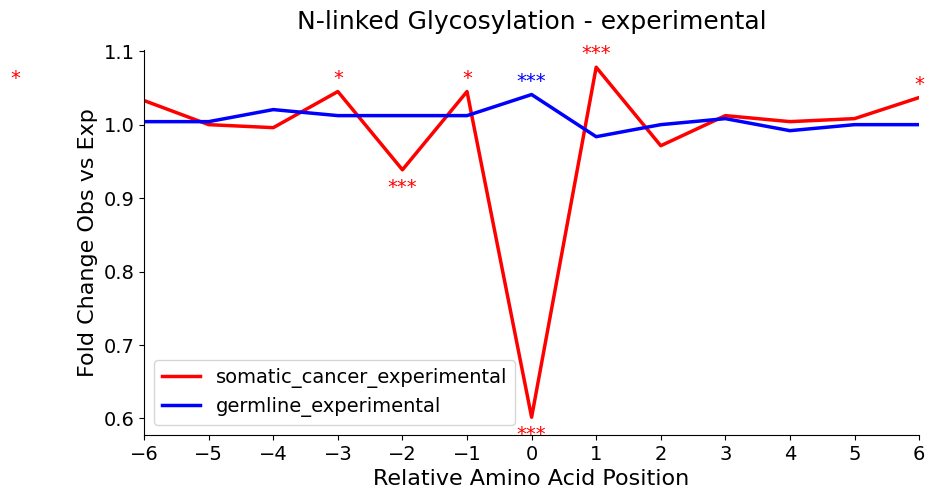

In [6]:
make_plotdata.DATA_DIR = "data"
make_plotdata.PLOTS_DIR = "plots"
sys.argv = ["make_plotdata.py",
            "--glycotype",GLYCOTYPE,
            "--vartype","all",
            "--sitetype",SITETYPE]
make_plotdata.main()